# 03 · Análisis exploratorio orientado a hipótesis (Fase 2)

**Regla importante:** el EDA se hace **solo con el periodo de entrenamiento (enero–mayo)**.
¿Por qué? Porque en el EDA tomamos decisiones (qué variables usar, cuáles eliminar). Si miráramos junio o julio, esas decisiones estarían "contaminadas" por los datos con los que después vamos a evaluar, y el resultado final sería optimista. En la sección 2.4 (estabilidad) sí usamos junio, que es el mes de validación, pero **nunca** julio (test).

Contenido:
- 2.1 Tasa de inasistencia por cada variable (con intervalo de confianza del 95 %)
- 2.2 Validación de hipótesis
- 2.3 Correlación entre variables numéricas: redundancias
- 2.4 Estabilidad mes a mes
- Conclusiones y variables seleccionadas

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import funciones_inasistencia as fi
import funciones_modelado as fm

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
fm.estilo_graficos()

import json
from scipy.stats import chi2_contingency

dataset = pd.read_parquet("dataset_modelo.parquet")
train = dataset[dataset["particion"] == "train"].copy()
tasa_global = train["no_asiste"].mean()
print(f"Citas de entrenamiento: {len(train):,} | tasa de inasistencia: {tasa_global:.1%}")

Citas de entrenamiento: 211,402 | tasa de inasistencia: 32.0%


## 2.1 Tasa de inasistencia por variable

**Cómo leer los gráficos:** cada barra es la tasa de inasistencia de esa categoría. La línea negra sobre la barra es el **intervalo de confianza del 95 %**: si es corta, tenemos muchos datos y el valor es confiable. La línea naranja punteada es la tasa global. Una variable es útil si sus barras se **separan** claramente de la línea global.

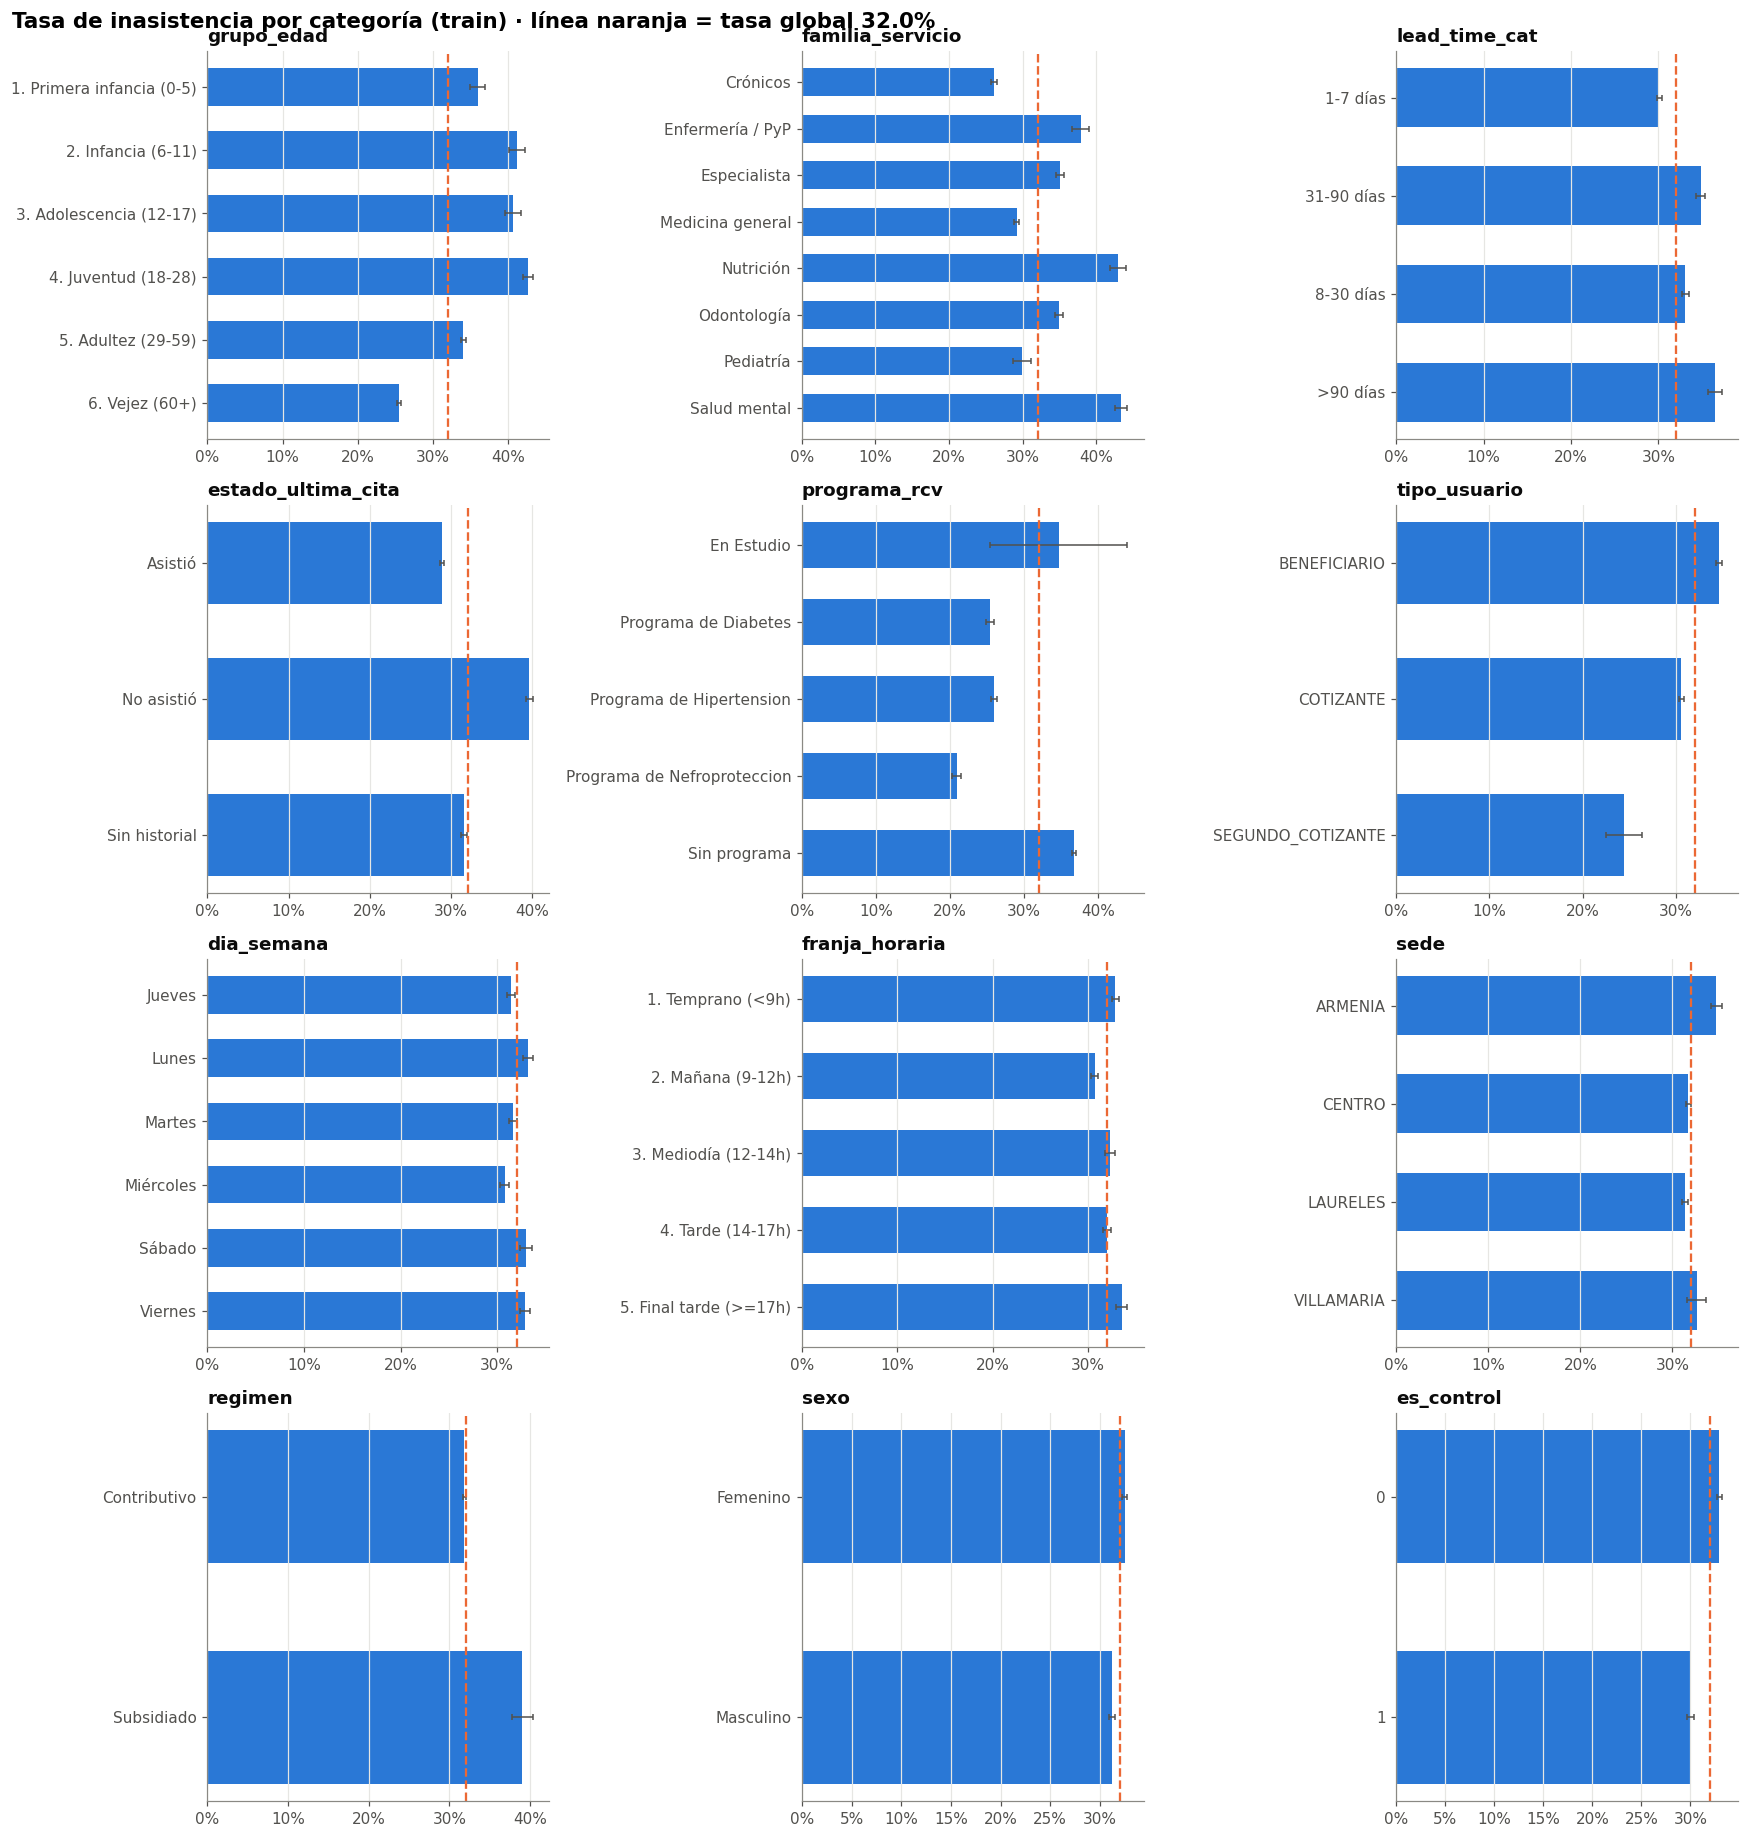

In [2]:
variables_categoricas = [
    "grupo_edad", "familia_servicio", "lead_time_cat", "estado_ultima_cita", "programa_rcv", "tipo_usuario",
    "dia_semana", "franja_horaria", "sede", "regimen", "sexo", "es_control",
]
fig, axes = plt.subplots(4, 3, figsize=(16, 17))
for ax, variable in zip(axes.flat, variables_categoricas):
    tabla = fm.tasa_por_categoria(train, variable).sort_values(variable)
    fm.grafico_tasa(ax, tabla, variable, tasa_global, horizontal=True)
fig.suptitle(f"Tasa de inasistencia por categoría (train) · línea naranja = tasa global {tasa_global:.1%}",
             x=0.01, ha="left", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

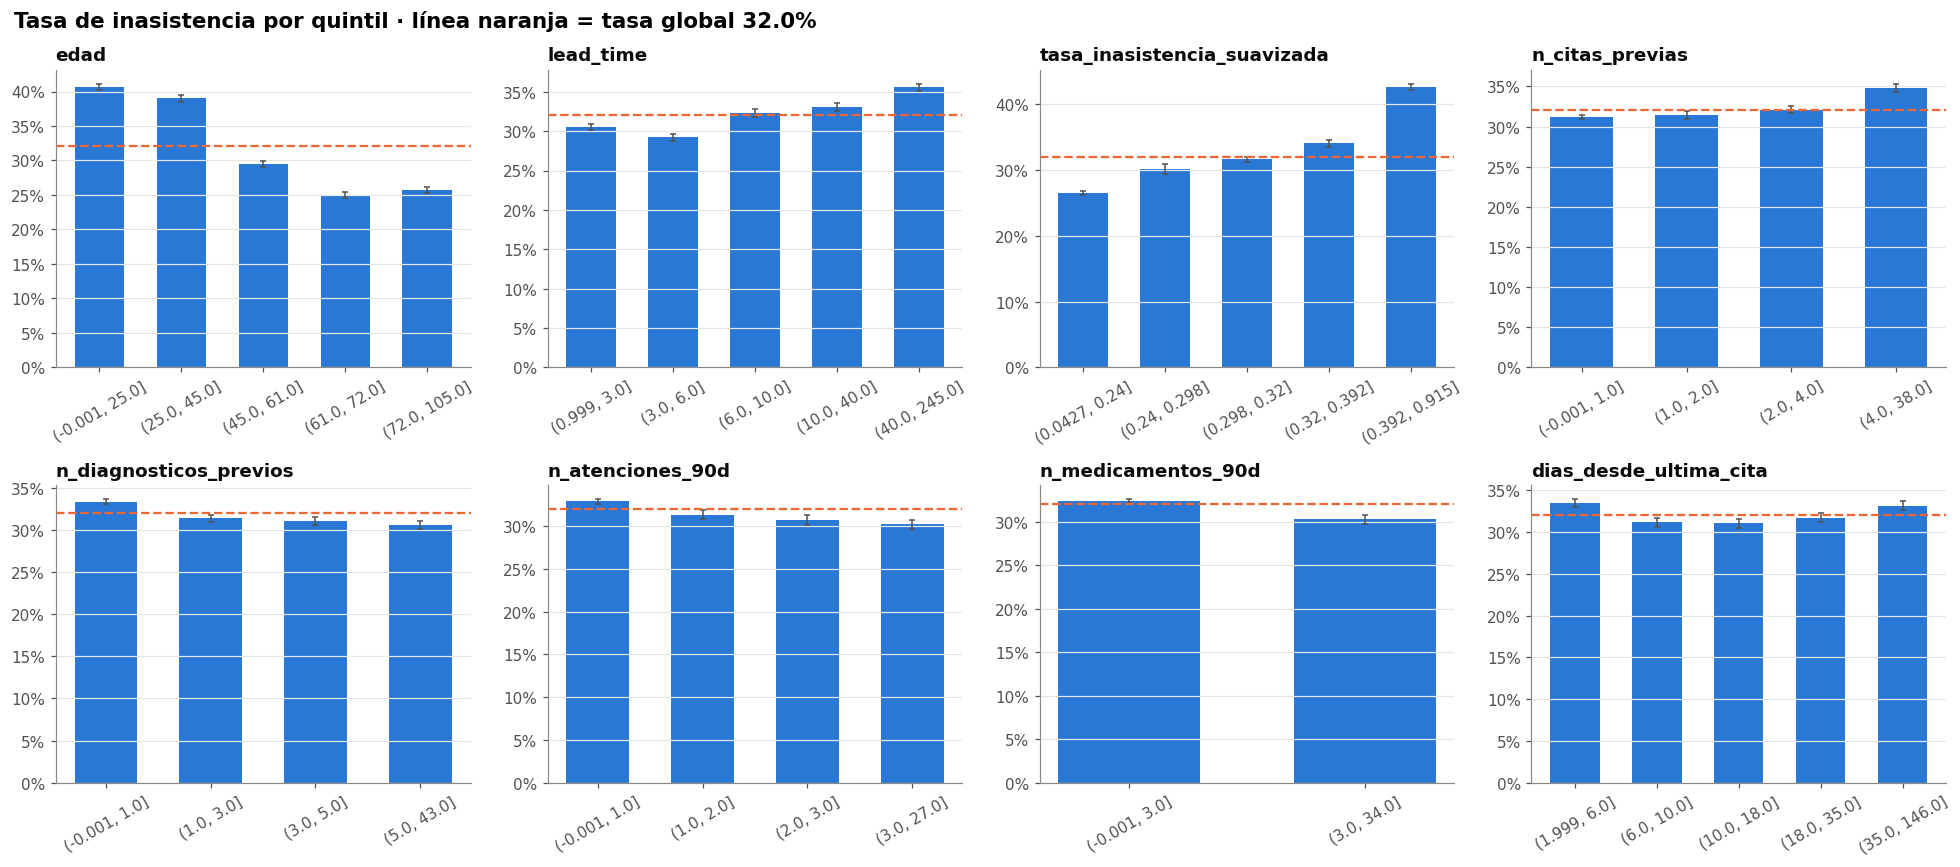

In [3]:
# Variables numéricas: las partimos en 5 grupos del mismo tamaño (quintiles)
variables_numericas = ["edad", "lead_time", "tasa_inasistencia_suavizada", "n_citas_previas",
                       "n_diagnosticos_previos", "n_atenciones_90d", "n_medicamentos_90d", "dias_desde_ultima_cita"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, variable in zip(axes.flat, variables_numericas):
    datos = train.dropna(subset=[variable]).copy()
    datos["rango"] = pd.qcut(datos[variable], 5, duplicates="drop").astype(str)
    tabla = fm.tasa_por_categoria(datos, "rango")
    tabla["orden"] = tabla["rango"].str.extract(r"\((-?[\d.]+)").astype(float)
    fm.grafico_tasa(ax, tabla.sort_values("orden"), "rango", tasa_global, titulo=variable)
fig.suptitle(f"Tasa de inasistencia por quintil · línea naranja = tasa global {tasa_global:.1%}",
             x=0.01, ha="left", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [4]:
# Variables binarias
binarias = ["es_puente_festivo", "es_dia_previo_festivo", "es_dia_posterior_festivo", "es_primer_dia_habil_mes",
            "es_ultimo_dia_habil_mes", "gestante_activa", "diabetes", "polifarmacia", "es_pac", "sin_historial"]
filas = []
for variable in binarias:
    tabla = train.groupby(variable)["no_asiste"].agg(["size", "mean"])
    p_valor = chi2_contingency(pd.crosstab(train[variable], train["no_asiste"]))[1]
    filas.append({"variable": variable, "citas_con_1": int(tabla.loc[1, "size"]), "tasa_si_0": tabla.loc[0, "mean"],
                  "tasa_si_1": tabla.loc[1, "mean"], "diferencia_pp": (tabla.loc[1, "mean"] - tabla.loc[0, "mean"]) * 100,
                  "p_valor": p_valor})
pd.DataFrame(filas).round({"tasa_si_0": 3, "tasa_si_1": 3, "diferencia_pp": 1}).sort_values("diferencia_pp", ascending=False)

,variable,citas_con_1,tasa_si_0,tasa_si_1,diferencia_pp,p_valor
3,es_primer_dia_habil_mes,7086,0.319,0.360,4.1,2.303475e-13
0,es_puente_festivo,3498,0.320,0.359,3.9,9.442599e-07
2,es_dia_posterior_festivo,8037,0.319,0.356,3.7,4.114329e-12
1,es_dia_previo_festivo,2128,0.320,0.347,2.7,8.980982e-03
5,gestante_activa,5035,0.320,0.346,2.6,8.118429e-05
4,es_ultimo_dia_habil_mes,9563,0.320,0.322,0.2,7.586231e-01
9,sin_historial,63027,0.322,0.316,-0.6,7.465659e-03
7,polifarmacia,26271,0.323,0.300,-2.3,4.769809e-14
6,diabetes,27728,0.332,0.244,-8.8,7.186595e-188
8,es_pac,120,0.320,0.192,-12.9,3.472306e-03


## 2.2 Validación de hipótesis

Para cada hipótesis comparamos tasas y aplicamos una **prueba chi-cuadrado**. Esta prueba responde: *"¿la diferencia que veo puede ser pura casualidad?"*. Un p-valor < 0,05 indica que la diferencia es estadísticamente significativa.

> **Ojo:** con 220 mil citas, casi cualquier diferencia sale "significativa". Por eso también miramos el **tamaño del efecto** (cuántos puntos porcentuales cambia la tasa). Lo que importa es si la diferencia es **grande**, no solo si es "real".

In [5]:
def probar_hipotesis(df, variable, descripcion):
    tabla = df.groupby(variable, observed=True)["no_asiste"].agg(citas="size", tasa="mean")
    tabla = tabla[tabla["citas"] >= 100]
    p_valor = chi2_contingency(pd.crosstab(df[variable], df["no_asiste"]))[1]
    print(f"{descripcion}\n  p-valor = {p_valor:.1e} | rango de tasas: {tabla['tasa'].min():.1%} a {tabla['tasa'].max():.1%} "
          f"({(tabla['tasa'].max() - tabla['tasa'].min()) * 100:.1f} pp)")
    display(tabla.round(3).T)

train["lunes_o_sabado"] = train["dia_semana"].isin(["Lunes", "Sábado"]).map({True: "Lunes/Sábado", False: "Mar-Vie"})

probar_hipotesis(train, "lead_time_cat", "H1: más lead time → más inasistencia")
probar_hipotesis(train, "grupo_edad", "H2: los jóvenes faltan más")
probar_hipotesis(train, "programa_rcv", "H3: los crónicos faltan menos")
probar_hipotesis(train, "lunes_o_sabado", "H4a: lunes y sábado → más inasistencia")
probar_hipotesis(train, "es_puente_festivo", "H4b: puentes festivos → más inasistencia")

H1: más lead time → más inasistencia
  p-valor = 6.4e-102 | rango de tasas: 30.1% a 36.5% (6.4 pp)


lead_time_cat,1-7 días,31-90 días,8-30 días,>90 días
citas,111683.000,34234.000,50795.000,14690.000
tasa,0.301,0.348,0.331,0.365


H2: los jóvenes faltan más
  p-valor = 0.0e+00 | rango de tasas: 25.5% a 42.7% (17.2 pp)


grupo_edad,1. Primera infancia (0-5),2. Infancia (6-11),3. Adolescencia (12-17),4. Juventud (18-28),5. Adultez (29-59),6. Vejez (60+)
citas,9677.00,8450.000,8139.000,24178.000,70720.000,90238.000
tasa,0.36,0.412,0.407,0.427,0.341,0.255


H3: los crónicos faltan menos
  p-valor = 0.0e+00 | rango de tasas: 20.9% a 36.7% (15.8 pp)


programa_rcv,En Estudio,Programa de Diabetes,Programa de Hipertension,Programa de Nefroproteccion,Sin programa
citas,101.000,20780.000,41847.000,19181.000,129493.000
tasa,0.347,0.254,0.259,0.209,0.367


H4a: lunes y sábado → más inasistencia
  p-valor = 2.3e-10 | rango de tasas: 31.6% a 33.1% (1.5 pp)


lunes_o_sabado,Lunes/Sábado,Mar-Vie
citas,54801.000,156601.000
tasa,0.331,0.316


H4b: puentes festivos → más inasistencia
  p-valor = 9.4e-07 | rango de tasas: 32.0% a 35.9% (3.9 pp)


es_puente_festivo,0,1
citas,207904.00,3498.000
tasa,0.32,0.359


In [6]:
def tasa(df, condicion):
    return df.loc[condicion, "no_asiste"].mean()

def tamano(pp):
    return "pequeño" if abs(pp) < 2 else ("moderado" if abs(pp) < 8 else "grande")

def p_valor(variable):
    return chi2_contingency(pd.crosstab(train[variable], train["no_asiste"]))[1]

programas = train["programa_rcv"].isin(["Programa de Diabetes", "Programa de Hipertension", "Programa de Nefroproteccion"])
hipotesis = [
    ("H1: más lead time → más inasistencia", "lead_time_cat", ">90 días vs. 1-7 días",
     tasa(train, train["lead_time_cat"] == ">90 días"), tasa(train, train["lead_time_cat"] == "1-7 días")),
    ("H2: los jóvenes faltan más", "grupo_edad", "Juventud vs. vejez",
     tasa(train, train["grupo_edad"] == "4. Juventud (18-28)"), tasa(train, train["grupo_edad"] == "6. Vejez (60+)")),
    ("H3: los crónicos faltan menos", "programa_rcv", "Sin programa vs. programas RCV",
     tasa(train, train["programa_rcv"] == "Sin programa"), tasa(train, programas)),
    ("H4a: lunes/sábado faltan más", "lunes_o_sabado", "Lunes/sábado vs. martes-viernes",
     tasa(train, train["lunes_o_sabado"] == "Lunes/Sábado"), tasa(train, train["lunes_o_sabado"] == "Mar-Vie")),
    ("H4b: puentes festivos faltan más", "es_puente_festivo", "Puente vs. no puente",
     tasa(train, train["es_puente_festivo"] == 1), tasa(train, train["es_puente_festivo"] == 0)),
]
filas = []
for nombre, variable, comparacion, tasa_riesgo, tasa_referencia in hipotesis:
    diferencia = (tasa_riesgo - tasa_referencia) * 100
    p = p_valor(variable)
    filas.append({"Hipótesis": nombre, "Comparación": comparacion,
                  "Tasas": f"{tasa_riesgo:.1%} vs. {tasa_referencia:.1%}",
                  "Diferencia (pp)": round(diferencia, 1), "Tamaño del efecto": tamano(diferencia),
                  "p-valor": f"{p:.1e}",
                  "Veredicto": "✅ Se confirma" if (diferencia > 0 and p < 0.05) else "❌ No se confirma"})
pd.DataFrame(filas).style.set_properties(**{"text-align": "left"})

,Hipótesis,Comparación,Tasas,Diferencia (pp),Tamaño del efecto,p-valor,Veredicto
0,H1: más lead time → más inasistencia,>90 días vs. 1-7 días,36.5% vs. 30.1%,6.400000,moderado,6.4e-102,✅ Se confirma
1,H2: los jóvenes faltan más,Juventud vs. vejez,42.7% vs. 25.5%,17.200000,grande,0.0e+00,✅ Se confirma
2,H3: los crónicos faltan menos,Sin programa vs. programas RCV,36.7% vs. 24.6%,12.100000,grande,0.0e+00,✅ Se confirma
3,H4a: lunes/sábado faltan más,Lunes/sábado vs. martes-viernes,33.1% vs. 31.6%,1.500000,pequeño,2.3e-10,✅ Se confirma
4,H4b: puentes festivos faltan más,Puente vs. no puente,35.9% vs. 32.0%,3.900000,moderado,9.4e-07,✅ Se confirma


**Notas sobre las hipótesis:**
- **H1 (lead time):** se confirma, pero en junio la relación se debilita y en parte se invierte (ver 2.4). Es una variable útil pero inestable.
- **H2 (edad):** efecto grande y estable. Es de las variables más fuertes.
- **H3 (crónicos):** efecto grande. Ojo: los crónicos también son mayores, así que parte del efecto es la edad.
- **H4 (calendario):** efectos reales pero pequeños (lunes/sábado) o que afectan a pocas citas (puentes, ~1,7 %).

In [7]:
# Hallazgos adicionales (calculados)
ultima = train.groupby("estado_ultima_cita")["no_asiste"].mean()
quintiles = train.groupby(pd.qcut(train["tasa_inasistencia_suavizada"], 5), observed=True)["no_asiste"].mean()
primer_dia = train.groupby("es_primer_dia_habil_mes")["no_asiste"].mean()
ultimo_dia_p = chi2_contingency(pd.crosstab(train["es_ultimo_dia_habil_mes"], train["no_asiste"]))[1]
poli = train.groupby("polifarmacia")["no_asiste"].mean()

print(f"- Estado de la última cita: quien faltó a su última cita falta {ultima['No asistió']:.1%}; quien asistió, {ultima['Asistió']:.1%}.")
print(f"- Tasa histórica suavizada: del quintil más bajo ({quintiles.iloc[0]:.1%}) al más alto ({quintiles.iloc[-1]:.1%}).")
print(f"- Primer día hábil del mes: {primer_dia[1]:.1%} vs. {primer_dia[0]:.1%} (posible efecto de la fecha de pago; inestable, ver 2.4).")
print(f"- Sin relación útil: último día hábil del mes (p = {ultimo_dia_p:.2f}) y polifarmacia ({(poli[1] - poli[0]) * 100:+.1f} pp).")

- Estado de la última cita: quien faltó a su última cita falta 39.6%; quien asistió, 28.9%.
- Tasa histórica suavizada: del quintil más bajo (26.5%) al más alto (42.6%).
- Primer día hábil del mes: 36.0% vs. 31.9% (posible efecto de la fecha de pago; inestable, ver 2.4).
- Sin relación útil: último día hábil del mes (p = 0.76) y polifarmacia (-2.3 pp).


## 2.3 Correlación entre variables numéricas

Usamos la **correlación de Spearman**, que mide si dos variables "suben juntas" aunque la relación no sea lineal. Si dos variables tienen |r| > 0,8, dicen casi lo mismo:
- A la **regresión logística** le hace daño: los coeficientes se vuelven inestables (**multicolinealidad**).
- A los **árboles** no les hace daño, pero tampoco aportan nada nuevo.

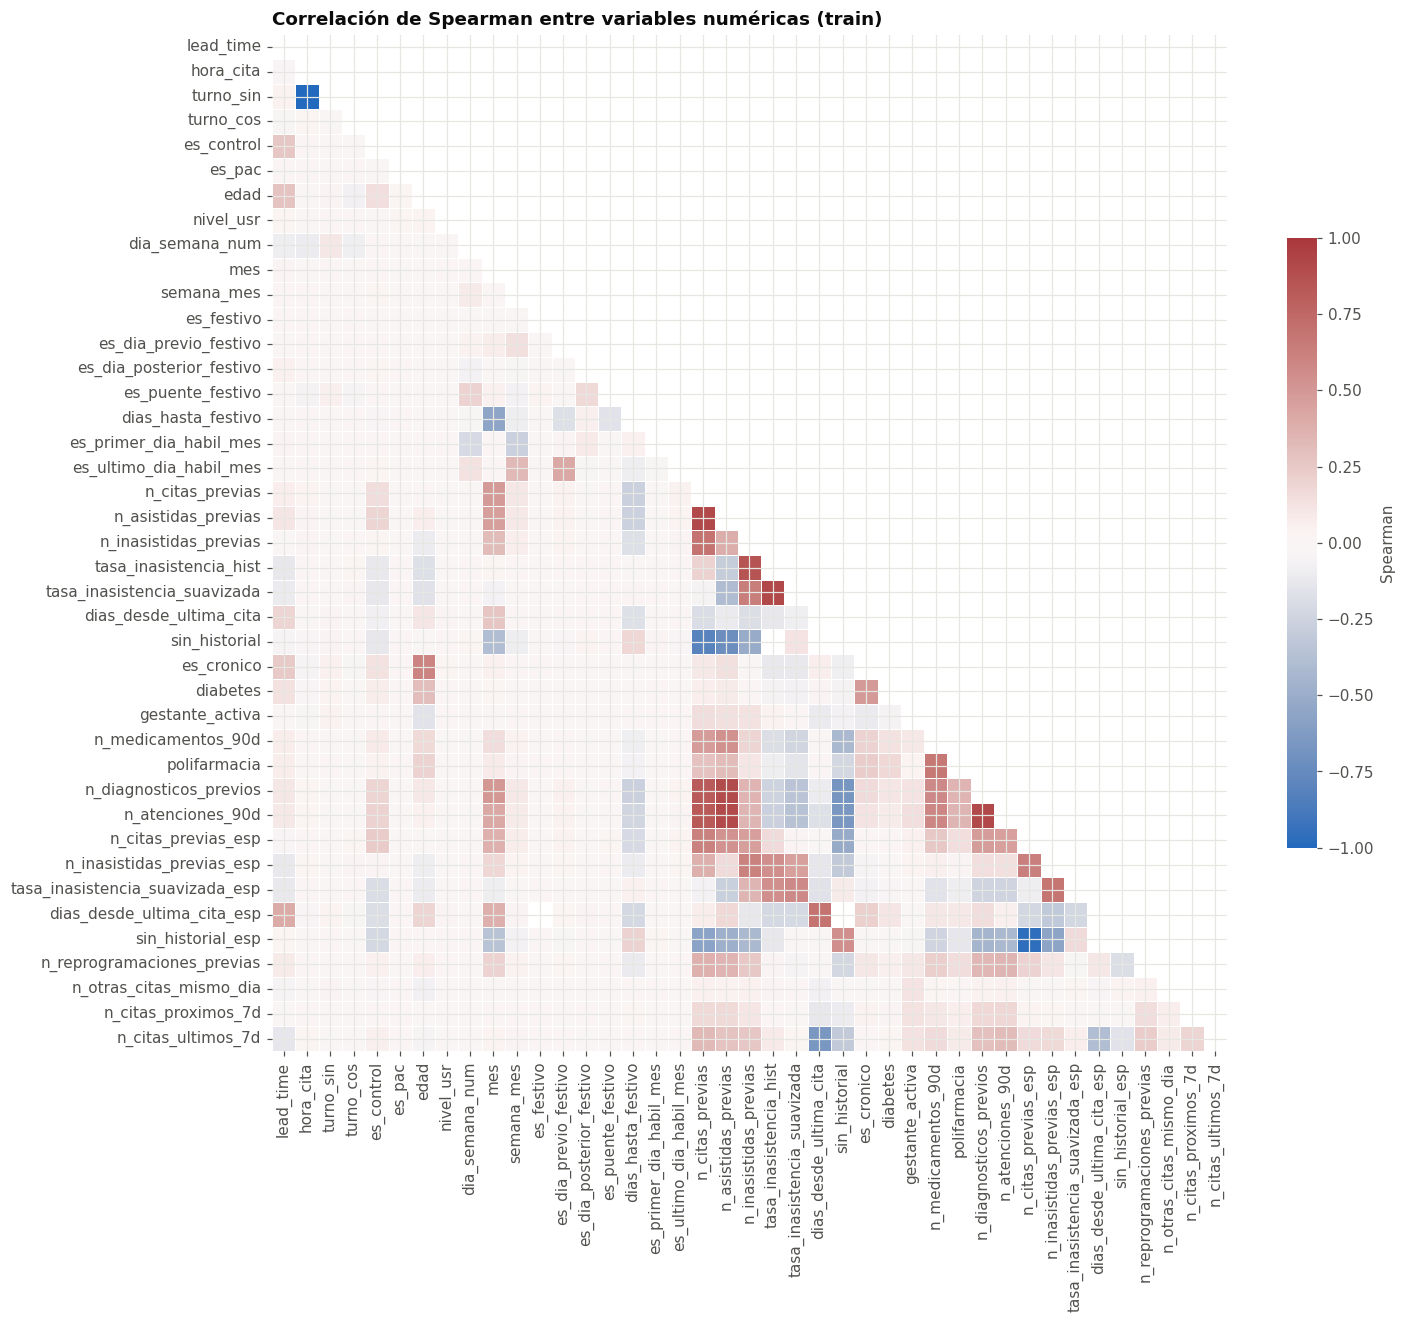

,variable_1,variable_2,spearman
0,hora_cita,turno_sin,-1.00
10,n_citas_previas_esp,sin_historial_esp,-0.97
1,n_citas_previas,n_asistidas_previas,0.91
8,tasa_inasistencia_hist,tasa_inasistencia_suavizada,0.91
9,n_diagnosticos_previos,n_atenciones_90d,0.91
6,n_asistidas_previas,n_atenciones_90d,0.90
5,n_asistidas_previas,n_diagnosticos_previos,0.89
7,n_inasistidas_previas,tasa_inasistencia_hist,0.85
3,n_citas_previas,n_diagnosticos_previos,0.82
4,n_citas_previas,n_atenciones_90d,0.82


In [8]:
numericas = [c for c in fi.VARIABLES_V1 + [v for b in fi.BLOQUES_V2.values() for v in b]
             if c in train.columns and train[c].dtype != object]
correlacion = train[numericas].corr(method="spearman")

fig, ax = plt.subplots(figsize=(14, 12))
mascara = np.triu(np.ones_like(correlacion, dtype=bool))
sns.heatmap(correlacion, mask=mascara, cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor="white", cbar_kws={"shrink": 0.6, "label": "Spearman"})
ax.set_title("Correlación de Spearman entre variables numéricas (train)")
plt.show()

pares = []
for i, a in enumerate(numericas):
    for b in numericas[i + 1:]:
        if abs(correlacion.loc[a, b]) > 0.8:
            pares.append({"variable_1": a, "variable_2": b, "spearman": round(correlacion.loc[a, b], 2)})
pd.DataFrame(pares).sort_values("spearman", key=abs, ascending=False)

**Decisiones sobre redundancias:**

| Se elimina | Motivo |
|---|---|
| `hora_cita` | Correlación −1 con `turno_sin`: la hora ya está en la codificación cíclica + franja |
| `dia_semana_num` | Es el mismo `dia_semana` en número |
| `n_asistidas_previas` | Es exactamente `n_citas_previas − n_inasistidas_previas` (dependencia lineal perfecta) |
| `tasa_inasistencia_hist` | r = 0,91 con la tasa suavizada, que además no tiene vacíos y maneja el arranque en frío |
| `sin_historial_esp` | r = −0,96 con `n_citas_previas_esp` |
| `es_cronico`, `polifarmacia`, `municipio`, `es_pac` | Se derivan directamente de `programa_rcv`, `n_medicamentos_90d`, `sede` y `especialidad` |
| `especialidad` (cruda) | Cambió de codificación en abril (notebook 01, sección 1.6); se usa `servicio_homologado` |

Se **mantienen** `n_diagnosticos_previos` y `n_atenciones_90d` (r ≈ 0,9 entre sí). Miden cosas distintas (carga de enfermedad vs. uso reciente) y la regularización de la logística controla su colinealidad. Lo verificamos en la Fase 4.

## 2.4 Estabilidad: ¿la relación se mantiene mes a mes?

Una variable es útil para predecir **el futuro** solo si su relación con la inasistencia es **estable**. Si en enero "los jóvenes faltan más" y en junio es al revés, el modelo aprenderá algo que no se sostiene.

**Métrica de estabilidad:** para cada mes ordenamos las categorías de mayor a menor inasistencia y comparamos ese orden con el orden promedio (correlación de Spearman). 1 = mismo orden todos los meses; valores bajos o negativos = relación inestable.

In [9]:
desarrollo = dataset[dataset["particion"].isin(["train", "validacion"])].copy()   # enero-junio (nunca julio)
desarrollo["mes_num"] = desarrollo["fecha_cita"].dt.month

def estabilidad(df, variable, min_citas=500):
    tabla = df.pivot_table(index=variable, columns="mes_num", values="no_asiste", aggfunc="mean")
    tabla = tabla[df.groupby(variable).size() >= min_citas]
    orden_promedio = tabla.mean(axis=1)
    return pd.Series({mes: tabla[mes].corr(orden_promedio, method="spearman") for mes in tabla.columns})

variables_estabilidad = ["estado_ultima_cita", "tipo_usuario", "programa_rcv", "grupo_edad", "familia_servicio",
                         "es_dia_posterior_festivo", "franja_horaria", "dia_semana", "sede", "lead_time_cat",
                         "es_control", "es_primer_dia_habil_mes", "sexo"]
tabla_estabilidad = pd.DataFrame({v: estabilidad(desarrollo, v) for v in variables_estabilidad}).T
tabla_estabilidad.columns = [f"mes_{m}" for m in tabla_estabilidad.columns]
tabla_estabilidad["minimo"] = tabla_estabilidad.min(axis=1)
tabla_estabilidad["promedio"] = tabla_estabilidad.drop(columns="minimo").mean(axis=1)
tabla_estabilidad.round(2).sort_values("promedio", ascending=False)

,mes_1,mes_2,mes_3,mes_4,mes_5,mes_6,minimo,promedio
estado_ultima_cita,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
tipo_usuario,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
es_dia_posterior_festivo,1.00,NaN,1.00,1.00,1.00,1.00,1.00,1.00
es_control,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
programa_rcv,0.80,1.00,1.00,1.00,1.00,1.00,0.80,0.97
grupo_edad,0.89,0.94,0.94,1.00,1.00,1.00,0.89,0.96
familia_servicio,0.98,0.88,0.88,0.95,0.98,0.83,0.83,0.92
dia_semana,0.54,0.71,0.66,0.60,0.83,0.94,0.54,0.71
es_primer_dia_habil_mes,1.00,1.00,1.00,1.00,1.00,-1.00,-1.00,0.67
sexo,1.00,1.00,1.00,1.00,1.00,-1.00,-1.00,0.67


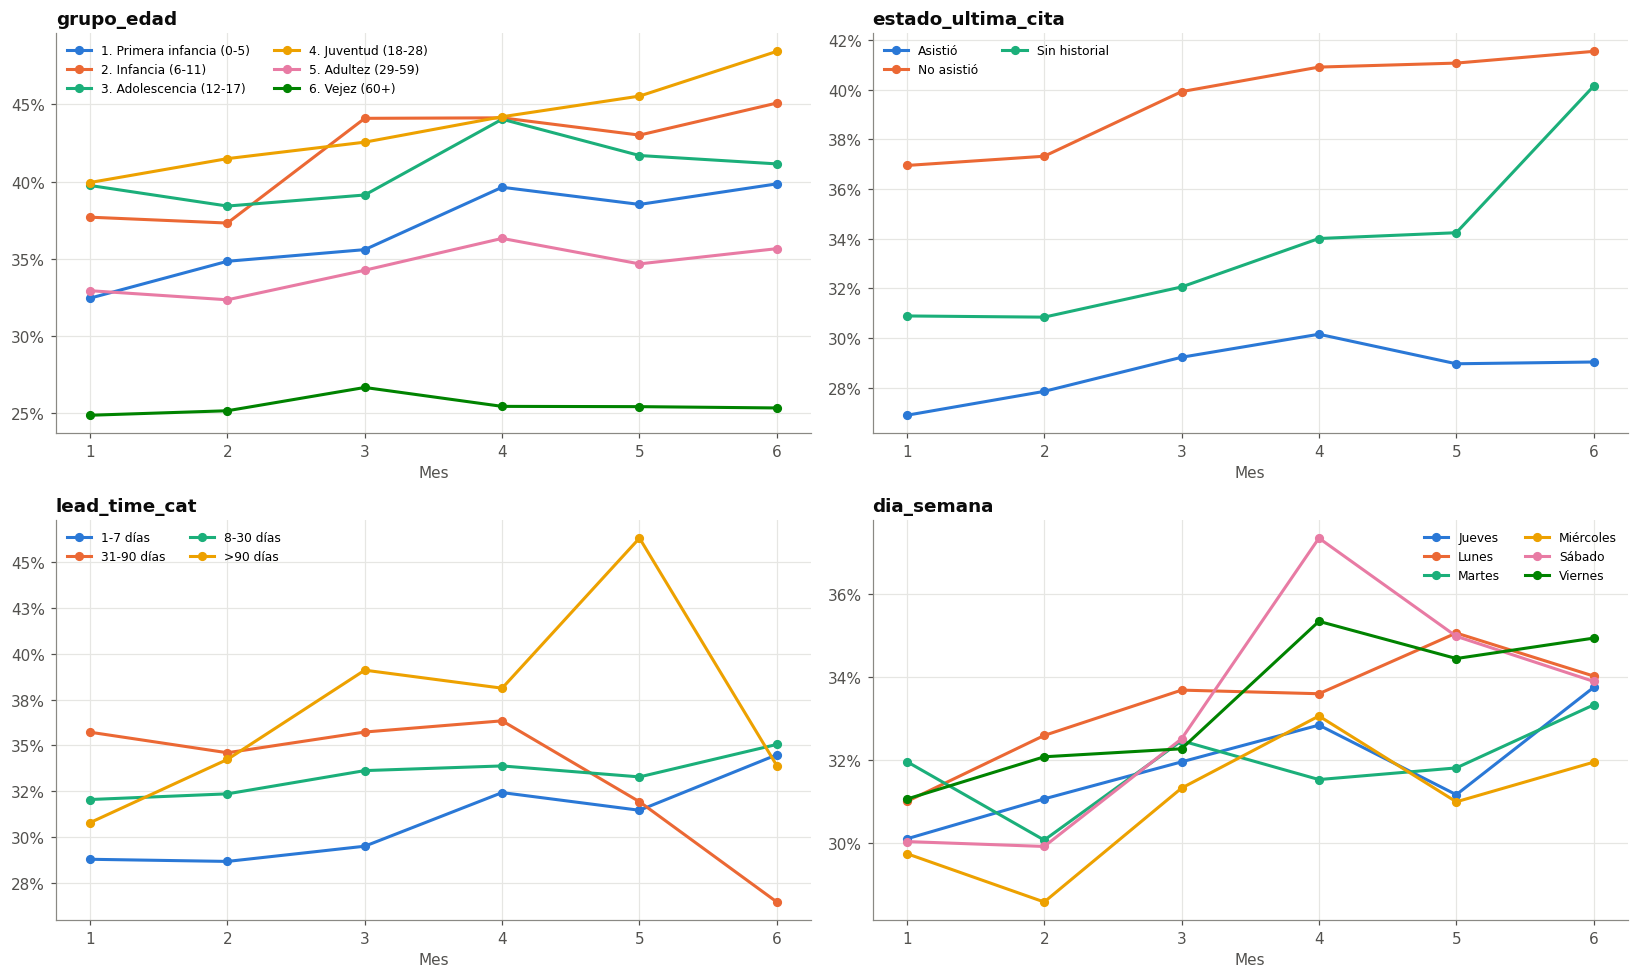

In [10]:
colores = [fm.AZUL, fm.NARANJA, fm.AQUA, fm.AMARILLO, "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, variable in zip(axes.flat, ["grupo_edad", "estado_ultima_cita", "lead_time_cat", "dia_semana"]):
    tabla = desarrollo.pivot_table(index="mes_num", columns=variable, values="no_asiste", aggfunc="mean")
    tabla = tabla[[c for c in tabla.columns if desarrollo[variable].eq(c).sum() >= 500]]
    for color, categoria in zip(colores, tabla.columns):
        ax.plot(tabla.index, tabla[categoria], color=color, linewidth=2, marker="o", markersize=5, label=str(categoria))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_title(variable)
    ax.set_xlabel("Mes")
    ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

**Lectura:**
- **Muy estables** (orden casi idéntico todos los meses): `estado_ultima_cita`, `tipo_usuario`, `programa_rcv`, `grupo_edad`, `familia_servicio`, festivos. Son la base confiable del modelo.
- **Inestables:** `lead_time_cat` (en junio las citas de 31–90 días faltan **menos** que las de 1–7 días, al revés que en los demás meses), `dia_semana`, `franja_horaria`, `sede` y `es_primer_dia_habil_mes`. Su efecto es pequeño y cambia de un mes a otro. No se eliminan (los árboles pueden usarlas combinadas con otras), pero **no se les debe dar una interpretación fuerte**.
- **`mes` se elimina:** con solo 5 meses de entrenamiento no se puede aprender estacionalidad. Además, en producción aparecen meses que el modelo nunca vio (agosto, septiembre…), y un árbol los trataría como "mayo".

## Conclusiones y variables seleccionadas (entrada para la Fase 4)

In [11]:
eliminar_v1 = ["hora_cita", "dia_semana_num", "n_asistidas_previas", "tasa_inasistencia_hist", "polifarmacia",
               "es_cronico", "municipio", "mes", "es_pac", "es_ultimo_dia_habil_mes", "especialidad"]
eliminar_v2 = ["sin_historial_esp"]

variables_v1 = [v for v in fi.VARIABLES_V1 if v not in eliminar_v1]
bloques_v2 = {bloque: [v for v in lista if v not in eliminar_v2] for bloque, lista in fi.BLOQUES_V2.items()}

seleccion = {"variables_v1": variables_v1, "bloques_v2": bloques_v2,
             "eliminadas_eda": eliminar_v1 + eliminar_v2}
with open("modelos/seleccion_eda.json", "w", encoding="utf-8") as archivo:
    json.dump(seleccion, archivo, ensure_ascii=False, indent=2)

print(f"Variables v1 que pasan a la Fase 4: {len(variables_v1)}")
print(variables_v1)

Variables v1 que pasan a la Fase 4: 35
['lead_time', 'lead_time_cat', 'franja_horaria', 'turno_sin', 'turno_cos', 'es_control', 'servicio_homologado', 'familia_servicio', 'edad', 'grupo_edad', 'sexo', 'nivel_usr', 'tipo_usuario', 'regimen', 'sede', 'dia_semana', 'semana_mes', 'es_festivo', 'es_dia_previo_festivo', 'es_dia_posterior_festivo', 'es_puente_festivo', 'dias_hasta_festivo', 'es_primer_dia_habil_mes', 'n_citas_previas', 'n_inasistidas_previas', 'tasa_inasistencia_suavizada', 'estado_ultima_cita', 'dias_desde_ultima_cita', 'sin_historial', 'programa_rcv', 'diabetes', 'gestante_activa', 'n_medicamentos_90d', 'n_diagnosticos_previos', 'n_atenciones_90d']


**Resumen del EDA**
1. Las variables más fuertes son de **persona e historial**: edad, programa crónico, tipo de usuario, estado de la última cita y tasa histórica. Todas son estables en el tiempo.
2. Las variables de **agenda y calendario** (lead time, día, hora, sede) tienen efectos pequeños e inestables.
3. Se eliminan 12 variables redundantes, sin señal o no estables en su codificación.
4. Esto anticipa un techo realista: el comportamiento del paciente se predice **parcialmente**. Una AUC cercana a 0,70 sería un resultado sólido con esta etiqueta.